# Who will miss their next credit card payment? A credit risk model, built to be used

30,000 credit card clients of a Taiwanese bank, with six months of payment history, and one question: **who will default next month?** Anyone can fit a classifier; the parts that decide whether it is usable are the ones this notebook spends its time on:

1. **Are the probabilities honest?** A bank does not need a yes or no, it needs "this client has a 35% chance of default", and that number has to mean 35%. The notebook checks calibration and tests whether repairing it helps.
2. **Where is the cut-off?** The best threshold depends on what a mistake costs. Missing a defaulter costs far more than turning away a good client, so the cut-off is chosen by expected cost, and the notebook shows how it moves when the costs change.
3. **Is it fair?** The model is audited by sex, education, marital status and age: who is approved, who is wrongly rejected, who is wrongly approved.

**Data:** [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) from the UCI Machine Learning Repository (Yeh and Lien, 2009; CC BY 4.0). The notebook downloads it (about 5.5 MB) into `CREDIT_DIR` on the first run.

In [1]:
import os
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path(os.environ.get("CREDIT_DIR", "credit_data"))
DATA_DIR.mkdir(exist_ok=True)
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})

## 1. Load and tidy the data

Some codes are not documented: education has values 0, 5 and 6 and marital status has 0, which are grouped with "other". The payment-status columns (`PAY_1` is the most recent month) count months of delay: -2 means no consumption, -1 paid in full, 0 paid the minimum, 1 and more are months behind.

In [2]:
zip_path = DATA_DIR / "default_credit.zip"
if not zip_path.exists():
    urllib.request.urlretrieve("https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip", zip_path)
with zipfile.ZipFile(zip_path) as z:
    raw = pd.read_excel(z.open("default of credit card clients.xls"), header=1)
df = raw.rename(columns={"PAY_0": "PAY_1", "default payment next month": "default"}).drop(columns="ID")
df["EDUCATION"] = df.EDUCATION.where(df.EDUCATION.isin([1, 2, 3]), 4)          # 1 graduate school, 2 university, 3 high school, 4 other
df["MARRIAGE"] = df.MARRIAGE.where(df.MARRIAGE.isin([1, 2]), 3)               # 1 married, 2 single, 3 other
print(f"{len(df):,} clients, {df.default.mean():.1%} defaulted the following month")
df[["LIMIT_BAL", "AGE", "PAY_1", "BILL_AMT1", "PAY_AMT1", "default"]].describe().round(1).T

30,000 clients, 22.1% defaulted the following month


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.3,129747.7,10000.0,50000.0,140000.0,240000.0,1000000.0
AGE,30000.0,35.5,9.2,21.0,28.0,34.0,41.0,79.0
PAY_1,30000.0,-0.0,1.1,-2.0,-1.0,0.0,0.0,8.0
BILL_AMT1,30000.0,51223.3,73635.9,-165580.0,3558.8,22381.5,67091.0,964511.0
PAY_AMT1,30000.0,5663.6,16563.3,0.0,1000.0,2100.0,5006.0,873552.0
default,30000.0,0.2,0.4,0.0,0.0,0.0,0.0,1.0


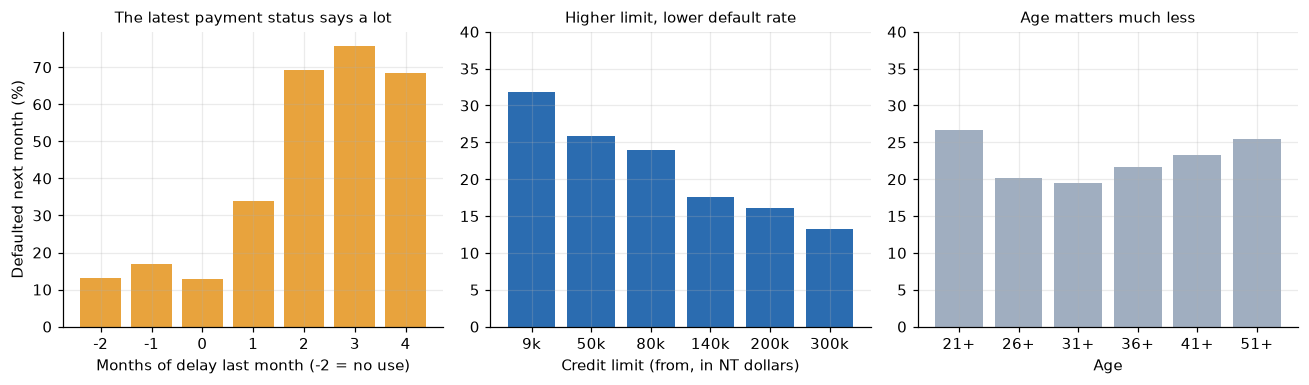

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
pay = df.groupby("PAY_1").default.agg(["mean", "size"])
pay = pay[pay["size"] >= 50]
axes[0].bar(pay.index.astype(str), pay["mean"] * 100, color=AMBER)
axes[0].set_xlabel("Months of delay last month (-2 = no use)")
axes[0].set_ylabel("Defaulted next month (%)")
axes[0].set_title("The latest payment status says a lot", fontsize=10)
limit = df.groupby(pd.qcut(df.LIMIT_BAL, 6, duplicates="drop"), observed=True).default.mean() * 100
axes[1].bar([f"{int(i.left / 1000)}k" for i in limit.index], limit.values, color=BLUE)
axes[1].set_xlabel("Credit limit (from, in NT dollars)")
axes[1].set_title("Higher limit, lower default rate", fontsize=10)
age = df.groupby(pd.cut(df.AGE, [20, 25, 30, 35, 40, 50, 80]), observed=True).default.mean() * 100
axes[2].bar([f"{int(i.left) + 1}+" for i in age.index], age.values, color=GREY)
axes[2].set_xlabel("Age")
axes[2].set_title("Age matters much less", fontsize=10)
for ax in axes[1:]:
    ax.set_ylim(0, 40)
fig.tight_layout()
plt.show()

## 2. Features and the split

Besides the raw columns, a few ratios that a credit analyst would compute: how much of the limit is used (**utilisation**), how much of last month's bill was paid (**repayment ratio**), how many of the six months were late and the longest delay. **Sex is deliberately not a feature**: it is kept aside and used only to audit the model afterwards. The clients are split 60% / 20% / 20% into training, validation (used to calibrate and to choose the threshold) and a final test set, all with the same default rate.

In [4]:
pay_cols = [f"PAY_{i}" for i in range(1, 7)]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

feat = df.copy()
feat["utilisation"] = feat.BILL_AMT1 / feat.LIMIT_BAL
feat["repayment_ratio"] = (feat.PAY_AMT1 / feat.BILL_AMT2.where(feat.BILL_AMT2 > 0)).clip(0, 2).fillna(1)
feat["months_late"] = (feat[pay_cols] > 0).sum(axis=1)
feat["max_delay"] = feat[pay_cols].max(axis=1)
feat["avg_bill"] = feat[bill_cols].mean(axis=1)
feat["avg_payment"] = feat[amt_cols].mean(axis=1)

FEATURES = ["LIMIT_BAL", "EDUCATION", "MARRIAGE", "AGE"] + pay_cols + bill_cols + amt_cols + [
    "utilisation", "repayment_ratio", "months_late", "max_delay", "avg_bill", "avg_payment"]

idx_train, idx_rest = train_test_split(feat.index, test_size=0.4, stratify=feat.default, random_state=0)
idx_valid, idx_test = train_test_split(idx_rest, test_size=0.5, stratify=feat.default[idx_rest], random_state=0)
X, y = feat[FEATURES], feat.default
print(f"train {len(idx_train):,} | validation {len(idx_valid):,} | test {len(idx_test):,}; default rate {y[idx_train].mean():.3f} / {y[idx_valid].mean():.3f} / {y[idx_test].mean():.3f}")

train 18,000 | validation 6,000 | test 6,000; default rate 0.221 / 0.221 / 0.221


## 3. Two models

A **logistic regression** on standardised features (simple, transparent, what many banks still use) and a **gradient-boosted tree** model (`HistGradientBoostingClassifier`, which finds interactions on its own). Because defaults are rare, accuracy is useless (always predicting "no default" is 78% accurate), so the metrics are **ROC AUC** (how well clients are ranked), **average precision** (quality of the ranking among the likely defaulters), and **log-loss** and the **Brier score** (quality of the probabilities themselves).

In [5]:
models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Gradient boosting": HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, max_leaf_nodes=15, l2_regularization=1.0,
                                                         early_stopping=True, validation_fraction=0.15, random_state=0),
}
for model in models.values():
    model.fit(X.loc[idx_train], y[idx_train])

def metrics(p, truth):
    return {"ROC AUC": roc_auc_score(truth, p), "avg precision": average_precision_score(truth, p),
            "log-loss": log_loss(truth, p), "Brier": brier_score_loss(truth, p)}

p_valid = {name: m.predict_proba(X.loc[idx_valid])[:, 1] for name, m in models.items()}
p_test = {name: m.predict_proba(X.loc[idx_test])[:, 1] for name, m in models.items()}
pd.DataFrame({name: metrics(p, y[idx_test]) for name, p in p_test.items()}).T.round(4)

,ROC AUC,avg precision,log-loss,Brier
Logistic regression,0.7451,0.5031,0.4541,0.1431
Gradient boosting,0.7739,0.5418,0.4344,0.1368


The two models rank clients almost equally well, which is typical for credit data where one variable (the latest payment status) does most of the work. Does adding **sex** help, if it were allowed? A quick check, for the record only:

In [6]:
with_sex = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X.loc[idx_train].assign(SEX=df.SEX), y[idx_train])
auc_with = roc_auc_score(y[idx_test], with_sex.predict_proba(X.loc[idx_test].assign(SEX=df.SEX))[:, 1])
print(f"logistic AUC without sex {roc_auc_score(y[idx_test], p_test['Logistic regression']):.4f}, with sex {auc_with:.4f}")

logistic AUC without sex 0.7451, with sex 0.7474


## 4. Are the probabilities honest?

A **reliability curve** groups clients by their predicted probability of default and compares it with the share that really defaulted. A well calibrated model sits on the diagonal. **Isotonic regression** fitted on the validation clients is the standard repair for a model that is off, and the test clients show whether it actually helps, which is not guaranteed.

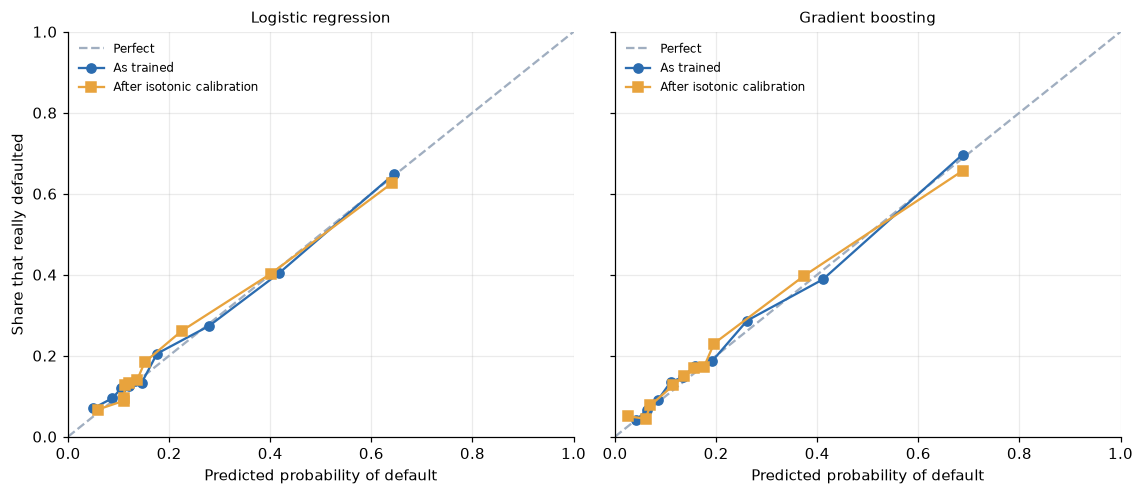

,Brier,log-loss
Logistic regression (raw),0.1431,0.4541
Logistic regression (calibrated),0.1436,0.4538
Gradient boosting (raw),0.1368,0.4344
Gradient boosting (calibrated),0.1375,0.4406


In [7]:
calibrators = {name: IsotonicRegression(out_of_bounds="clip").fit(p_valid[name], y[idx_valid]) for name in models}
p_test_cal = {name: calibrators[name].predict(p_test[name]) for name in models}

def reliability(p, truth, bins=10):
    edges = np.quantile(p, np.linspace(0, 1, bins + 1))
    which = np.clip(np.searchsorted(edges, p, side="right") - 1, 0, bins - 1)
    return np.array([(p[which == b].mean(), truth[which == b].mean()) for b in range(bins) if (which == b).sum() > 20])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), sharey=True)
for ax, name in zip(axes, models):
    ax.plot([0, 1], [0, 1], color=GREY, ls="--", label="Perfect")
    raw_pts = reliability(p_test[name], y[idx_test].to_numpy())
    cal_pts = reliability(p_test_cal[name], y[idx_test].to_numpy())
    ax.plot(raw_pts[:, 0], raw_pts[:, 1], marker="o", color=BLUE, label="As trained")
    ax.plot(cal_pts[:, 0], cal_pts[:, 1], marker="s", color=AMBER, label="After isotonic calibration")
    ax.set_xlabel("Predicted probability of default")
    ax.set_title(name, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
axes[0].set_ylabel("Share that really defaulted")
fig.tight_layout()
plt.show()
pd.DataFrame({f"{name} ({kind})": {"Brier": brier_score_loss(y[idx_test], p), "log-loss": log_loss(y[idx_test], np.clip(p, 1e-6, 1 - 1e-6))}
              for name in models for kind, p in [("raw", p_test[name]), ("calibrated", p_test_cal[name])]}).T.round(4)

## 5. Where should the cut-off be?

A client is **rejected** when the predicted probability of default exceeds a threshold `t`. Every choice of `t` trades two errors:

- a **missed defaulter** (approved, then defaults) costs the bank a loss, set here to **3 units**;
- a **rejected good client** costs the margin the bank would have earned, set here to **1 unit**.

These costs are an assumption, not data (the real ratio is a business decision, and this notebook shows how much the answer depends on it). The threshold is picked on the **validation** clients, where the calibrated probabilities give the expected cost directly, and then judged on the test clients.

In [8]:
BEST = "Gradient boosting"
thresholds = np.linspace(0.05, 0.95, 91)

def cost_per_client(p, truth, threshold, c_miss, c_reject):
    rejected = p >= threshold
    missed = (~rejected) & (truth == 1)
    wrongly_rejected = rejected & (truth == 0)
    return (c_miss * missed.sum() + c_reject * wrongly_rejected.sum()) / len(truth)

p_v, y_v = calibrators[BEST].predict(p_valid[BEST]), y[idx_valid].to_numpy()
p_t, y_t = p_test_cal[BEST], y[idx_test].to_numpy()

rows = []
for c_miss in [2, 3, 5, 10]:
    costs_v = [cost_per_client(p_v, y_v, t, c_miss, 1) for t in thresholds]
    t_star = thresholds[int(np.argmin(costs_v))]
    rows.append({"cost of a miss (units)": c_miss, "best threshold": t_star,
                 "rejected (%)": (p_t >= t_star).mean() * 100,
                 "cost at best threshold": cost_per_client(p_t, y_t, t_star, c_miss, 1),
                 "cost at 0.5": cost_per_client(p_t, y_t, 0.5, c_miss, 1),
                 "cost of approving everyone": c_miss * y_t.mean()})
policy = pd.DataFrame(rows).set_index("cost of a miss (units)")
THRESHOLD = float(policy.loc[3, "best threshold"])
print(f"threshold used from here on (miss = 3 units): {THRESHOLD:.2f}")
policy.round(3)

threshold used from here on (miss = 3 units): 0.19


,best threshold,rejected (%),cost at best threshold,cost at 0.5,cost of approving everyone
cost of a miss (units),,,,,
2,0.30,16.050,0.316,0.331,0.442
3,0.19,23.750,0.416,0.476,0.664
5,0.15,47.450,0.564,0.768,1.106
10,0.08,71.767,0.696,1.496,2.212


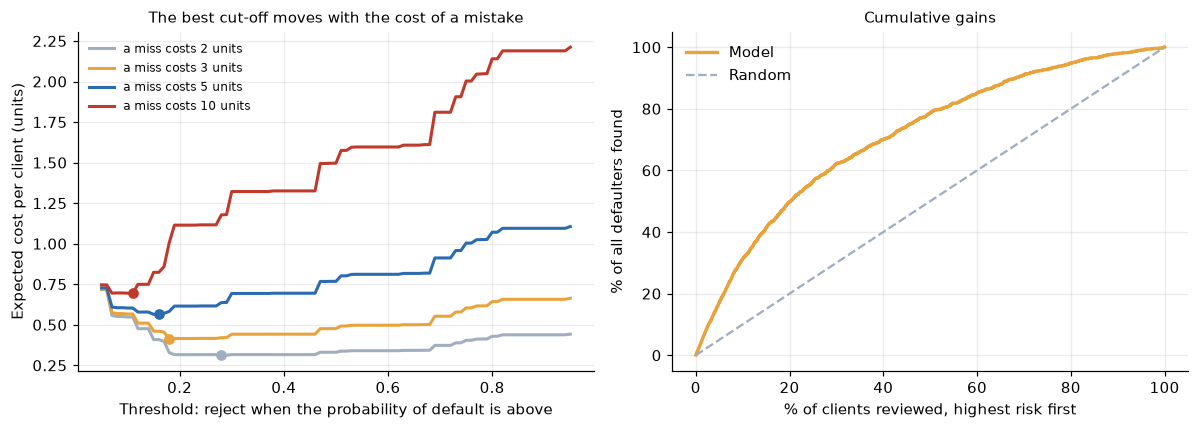

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for c_miss, color in [(2, GREY), (3, AMBER), (5, BLUE), (10, "#c0392b")]:
    costs = [cost_per_client(p_t, y_t, t, c_miss, 1) for t in thresholds]
    axes[0].plot(thresholds, costs, color=color, lw=2, label=f"a miss costs {c_miss} units")
    axes[0].scatter([thresholds[int(np.argmin(costs))]], [min(costs)], color=color, zorder=3)
axes[0].set_xlabel("Threshold: reject when the probability of default is above")
axes[0].set_ylabel("Expected cost per client (units)")
axes[0].set_title("The best cut-off moves with the cost of a mistake", fontsize=10)
axes[0].legend(frameon=False, fontsize=8)

order = np.argsort(-p_t)
captured = np.cumsum(y_t[order]) / y_t.sum() * 100
axes[1].plot(np.arange(1, len(order) + 1) / len(order) * 100, captured, color=AMBER, lw=2.2, label="Model")
axes[1].plot([0, 100], [0, 100], color=GREY, ls="--", label="Random")
axes[1].set_xlabel("% of clients reviewed, highest risk first")
axes[1].set_ylabel("% of all defaulters found")
axes[1].set_title("Cumulative gains", fontsize=10)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Is it fair? An audit by group

With the threshold fixed, the same decision rule is applied to every group and compared on four things: the group's **actual default rate**, its **approval rate**, the share of its good clients that are **wrongly rejected** (false positive rate), and the share of its defaulters that are **wrongly approved** (false negative rate). Large differences in the last two mean the model's mistakes fall unevenly. Sex is used here only to *audit*, it was never a feature.

In [10]:
audit_df = feat.loc[idx_test].assign(p=p_t, rejected=(p_t >= THRESHOLD))
audit_df["sex"] = audit_df.SEX.map({1: "male", 2: "female"})
audit_df["education"] = audit_df.EDUCATION.map({1: "graduate school", 2: "university", 3: "high school", 4: "other"})
audit_df["marital status"] = audit_df.MARRIAGE.map({1: "married", 2: "single", 3: "other"})
audit_df["age band"] = pd.cut(audit_df.AGE, [20, 29, 39, 49, 80], labels=["21-29", "30-39", "40-49", "50+"]).astype(str)

rows = []
for attribute in ["sex", "education", "marital status", "age band"]:
    for group, g in audit_df.groupby(attribute):
        if len(g) < 100:
            continue
        good, bad = g[g.default == 0], g[g.default == 1]
        rows.append({"attribute": attribute, "group": group, "clients": len(g), "defaulters": len(bad),
                     "default rate": g.default.mean(), "avg predicted": g.p.mean(),
                     "approved": 1 - g.rejected.mean(),
                     "good clients rejected": good.rejected.mean(),
                     "defaulters approved": 1 - bad.rejected.mean(),
                     "AUC": roc_auc_score(g.default, g.p)})
audit = pd.DataFrame(rows).set_index(["attribute", "group"])
audit.round(3)

clients  defaulters  default rate  \
attribute      group                                                
sex            female              3621         743         0.205   
               male                2379         584         0.245   
education      graduate school     2130         405         0.190   
               high school          980         260         0.265   
               university          2793         650         0.233   
marital status married             2691         642         0.239   
               single              3234         669         0.207   
age band       21-29               1958         422         0.216   
               30-39               2280         480         0.211   
               40-49               1216         276         0.227   
               50+                  546         149         0.273   

                                avg predicted  approved  \
attribute      group                                      
sex            female                   0.204     0.775   
               male                     0.222     0.744   
education      graduate school          0.188     0.795   
               high school              0.241     0.711   
               university               0.225     0.748   
marital status married                  0.217     0.751   
               single                   0.206     0.771   
age band       21-29                    0.222     0.751   
               30-39                    0.194     0.784   
               40-49                    0.207     0.775   
               50+                      0.255     0.687   

                                good clients rejected  defaulters approved  \
attribute      group                                                         
sex            female                           0.143                0.458   
               male                             0.159                0.443   
education      graduate school                  0.126                0.459   
               high school                      0.172                0.388   
               university                       0.166                0.463   
marital status married                          0.151                0.441   
               single                           0.147                0.457   
age band       21-29                            0.157                0.417   
               30-39                            0.144                0.512   
               40-49                            0.137                0.475   
               50+                              0.171                0.309   

                                  AUC  
attribute      group                   
sex            female           0.771  
               male             0.772  
education      graduate school  0.789  
               high school      0.774  
               university       0.759  
marital status married          0.775  
               single           0.772  
age band       21-29            0.785  
               30-39            0.758  
               40-49            0.762  
               50+              0.809

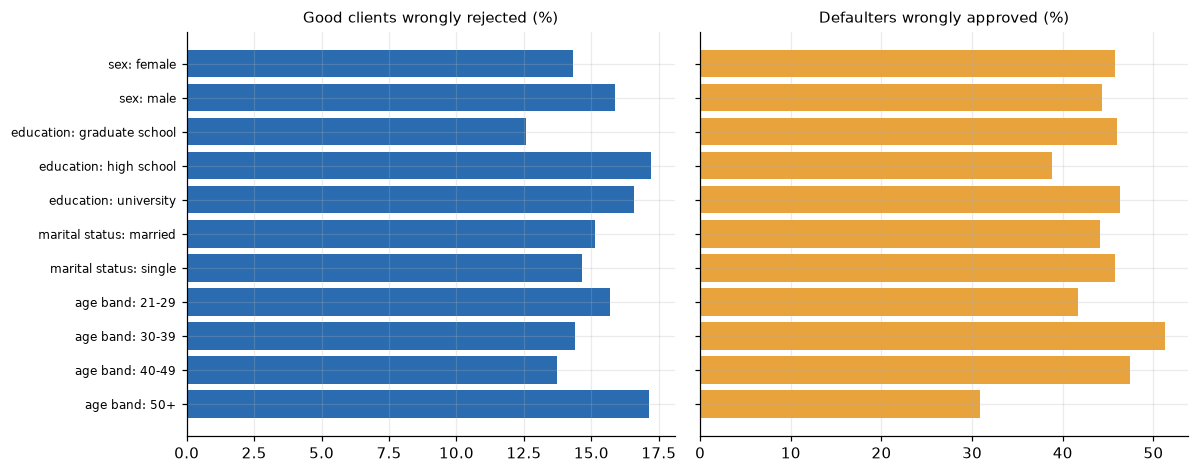

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
labels = [f"{a}: {g}" for a, g in audit.index]
y_pos = np.arange(len(audit))
axes[0].barh(y_pos, audit["good clients rejected"] * 100, color=BLUE)
axes[0].set_title("Good clients wrongly rejected (%)", fontsize=10)
axes[1].barh(y_pos, audit["defaulters approved"] * 100, color=AMBER)
axes[1].set_title("Defaulters wrongly approved (%)", fontsize=10)
axes[0].set_yticks(y_pos, labels, fontsize=8)
axes[0].invert_yaxis()
fig.tight_layout()
plt.show()

## 7. What drives the decisions?

**Permutation importance** shuffles one feature at a time on the test clients and measures how much the ROC AUC falls.

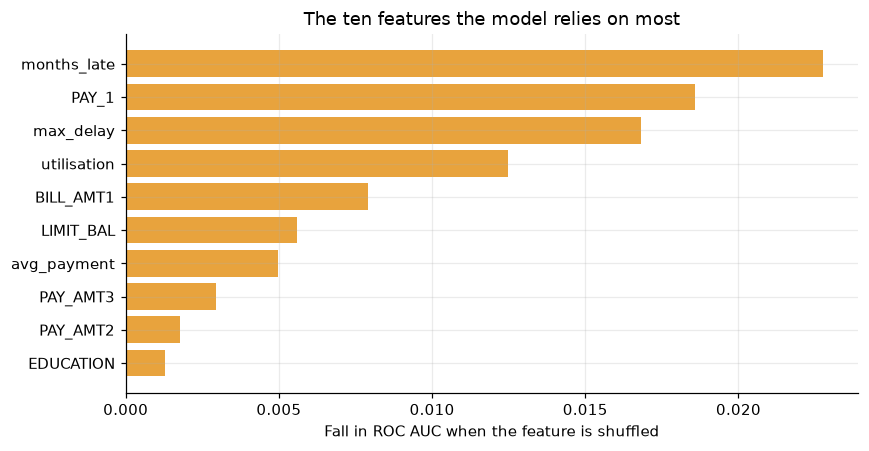

,AUC lost
months_late,0.0228
PAY_1,0.0186
max_delay,0.0168
utilisation,0.0125
BILL_AMT1,0.0079


In [12]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(models[BEST], X.loc[idx_test], y[idx_test], scoring="roc_auc", n_repeats=5, random_state=0)
importance = pd.Series(imp.importances_mean, index=FEATURES).sort_values().tail(10)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(importance.index, importance.values, color=AMBER)
ax.set_xlabel("Fall in ROC AUC when the feature is shuffled")
ax.set_title("The ten features the model relies on most")
fig.tight_layout()
plt.show()
importance.sort_values(ascending=False).round(4).to_frame("AUC lost").head(5)

## What the results say

- **One variable does most of the work.** 22.1% of the clients defaulted. Among the 22.7% who were already late on their last payment, 50% defaulted, against 13.8% of everyone else, and the rate climbs with the length of the delay (34% after one month, 69% after two, 76% after three). A higher credit limit also goes with fewer defaults (31.8% in the lowest limit band, 13.3% in the highest), while age matters much less (19-27% across bands, higher for the youngest and oldest clients).
- **A tree model ranks better, but both are decent.** On 6,000 test clients the logistic regression reaches a ROC AUC of 0.745 and the gradient-boosted trees 0.774 (average precision 0.50 against 0.54). Adding sex would raise the logistic AUC by only 0.002, from 0.745 to 0.747, so leaving it out costs almost nothing.
- **The probabilities were already honest, and calibration did not help.** The reliability curves of both models sit close to the diagonal as trained. Isotonic calibration, the usual repair, did not improve the Brier score (0.1368 before, 0.1375 after, for the trees) because there was little to repair. It is still worth checking: a model that ranks well can be badly calibrated, and a decision based on cost needs the probabilities to mean what they say.
- **The right cut-off depends on what a mistake costs.** With a missed defaulter costing 3 units and a wrongly rejected good client 1 unit (an assumption, not data), the best threshold is 0.19: reject 24% of clients, at an expected cost of 0.42 per client, against 0.48 at the default 0.5 threshold and 0.66 for approving everyone, so the model saves 37% of the cost of approving everybody. If a miss costs 2 units the best cut-off is 0.30 and 16% are rejected; at 5 units it is 0.15 and 47% are rejected; at 10 units 0.08 and 72%. The threshold is a business decision, and the model's job is to make its consequences visible.
- **A short review list captures most of the risk.** Reviewing the highest-risk 20% of clients finds about half of all defaulters, and the top 40% finds about 70%.
- **Even at the best cut-off the model misses a lot.** Roughly 45% of the clients who default are still approved. The data (one month of outcome, no income or employment details) simply does not contain enough to do much better.
- **The audit shows modest gaps, and small samples.** Women are approved a little more often than men (77.5% against 74.4%), and the model ranks both equally well (AUC 0.771 and 0.772). Women have a lower actual default rate (20.5% against 24.5%), and the model slightly *underestimates* the risk for the higher-risk groups (men: 22.2% predicted against 24.5% actual; high school graduates: 24.1% against 26.5%). The largest difference is by age: of the clients who later default, 51% of those aged 30-39 had been approved against 31% of those over 50. With 480 and 149 defaulters in those groups that gap is bigger than sampling noise would explain, whereas gaps of a point or two (between women and men) are not. None of this is evidence of discrimination, and none of it proves there is none.
- **What the model uses.** Shuffling the number of late months costs the most AUC (0.023), followed by the latest payment status (0.019), the longest delay (0.017) and how much of the limit is in use (0.013). Payment behaviour dominates; demographics hardly matter.

**Limits:** one month of outcomes from a Taiwanese bank in 2005; the cost assumptions are illustrative; sex is excluded from the model but marital status, education and age are not, which a real lender may be forbidden to use; group differences rest on small numbers; the split is random, not by time, so there is no check against a change in the economy.

**Techniques covered:** logistic regression and gradient boosting, stratified train / validation / test split, ROC AUC, average precision, Brier score and log-loss, reliability curves and isotonic calibration, expected-cost threshold selection with sensitivity analysis, cumulative gains, a fairness audit by group, permutation importance.
